# Laboratorio de regresión - 2

## Significancia de factores

|                |   |
:----------------|---|
| **Nombre**     Juan Pablo Moran|   |
| **Fecha**      |   |
| **Expediente** 753760|   |

Descarga el archivo de publicidad y carga los datos (Advertising.csv).

In [1]:
import pandas as pd

df = pd.read_csv("Advertising.csv", index_col=0)
print(df.shape)
df.head()

(200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Los datos se cargan sin problema: **200 observaciones** y **4 columnas** (`TV`, `radio`, `newspaper`, `sales`). Las primeras tres son presupuestos de publicidad (en miles de dólares) en cada medio, y `sales` son las ventas del producto (en miles de unidades) en cada uno de los 200 mercados.

**¿Hay alguna relación entre el presupuesto para publicidad y las ventas?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- ¿Por qué? ¿Qué resultaría si nos diéramos cuenta de la falta de relación entre el presupuesto de publicidad y las ventas?

TV           0.782224
radio        0.576223
newspaper    0.228299
sales        1.000000
Name: sales, dtype: float64

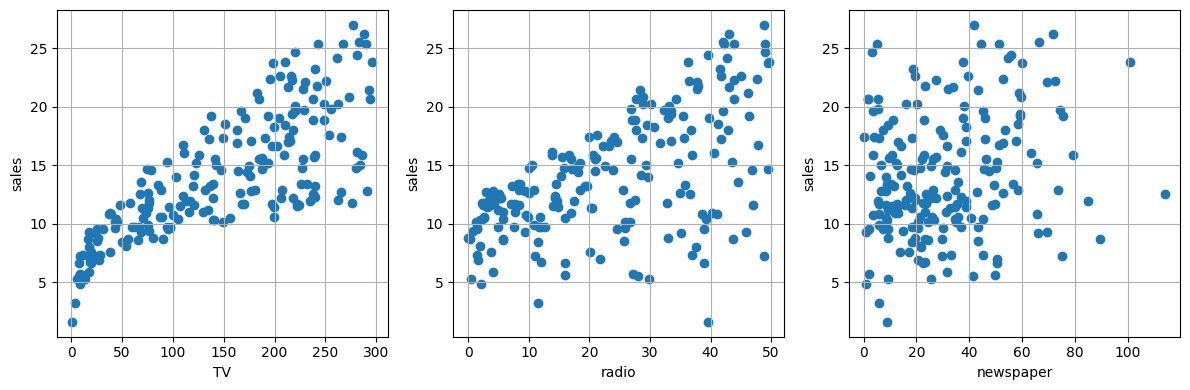

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["TV", "radio", "newspaper"]):
    ax.scatter(df[col], df["sales"])
    ax.set_xlabel(col)
    ax.set_ylabel("sales")
    ax.grid()
plt.tight_layout()

df.corr()["sales"]

Sí parece haber relación, sobre todo con `TV` y `radio`: la nube de puntos crece de forma más o menos lineal conforme aumenta el gasto. Con `newspaper` la relación se ve más débil y dispersa. Las correlaciones con `sales` lo confirman:

| Medio | Correlación con sales |
|---|---|
| TV | 0.7822 |
| radio | 0.5762 |
| newspaper | 0.2283 |

Si no hubiera relación entre el presupuesto de publicidad y las ventas, estaríamos gastando dinero en publicidad sin ningún efecto medible sobre lo que realmente importa (las ventas); en ese caso lo razonable sería redirigir ese presupuesto a otra cosa, o dejar de invertir en publicidad.

**¿Qué tan fuerte es esta relación?**
Asumiendo que existe esta relación, ¿nos sirve conocer el impacto que tiene invertir en publicidad en las ventas?

Las correlaciones ya dan una primera idea (TV y radio se relacionan bastante más con `sales` que newspaper), pero para cuantificar la fuerza de la relación de forma más precisa usamos $R^2$, que calculamos más abajo junto con cada regresión: nos dice qué porcentaje de la variación en las ventas queda explicado por el gasto en cada medio. Sí nos sirve conocer el impacto: si la relación es fuerte y consistente, podemos usarla para decidir cuánto presupuesto asignar a cada medio y para predecir ventas futuras dado un presupuesto propuesto.

**¿Cuáles medios están asociados con las ventas? ¿Qué tan grande es la asociación entre un medio específico y las ventas?**

Hay 3 medios distintos en los datos. ¿Sirve invertir en los 3? ¿Conviene más invertir sólo en uno?

**¿Qué tan seguros estamos de que podríamos predecir ventas futuras?**

**¿La relación es lineal?**

**¿Hay sinergia entre estos medios?**

Puede ser que gastar \\$50,000 en publicidad y otros \\$50,000 en radio es mejor opción que gastar \\$100,000 en televisión. A esto le llamamos efecto de interacción.

Podemos usar regresión lineal para responder todas estas preguntas.

Realiza una regresión lineal:

$$ \text{ventas} \approx \beta_0 + (\beta_1)(\text{TV})$$

In [3]:
from sklearn.linear_model import LinearRegression

X_tv = df[["TV"]].values
y = df["sales"].values

lr_tv = LinearRegression().fit(X_tv, y)
print(lr_tv.intercept_)
print(lr_tv.coef_)

7.032593549127695
[0.04753664]


El modelo ajustado es:

$$\hat{\text{sales}} = 7.0326 + 0.0475\,\text{TV}$$

Es decir, sin publicidad en TV se venderían en promedio **7,032.6 unidades**, y por cada **\$1,000** adicionales en TV las ventas suben en promedio **47.5 unidades**.

### Verificando la precisión de nuestros coeficientes estimados

Recuerda que en el mundo real hay ruidos y errores de medición. Siempre se asume que la verdadera relación entre $X$ y $Y$ es $$Y = \beta_0 + \beta_1 X + \epsilon$$

Se asume que el término de error es independiente de $X$ (el error siempre es el mismo sin importar el valor de $X$). Este modelo describe a la *línea de regresión de la población*, que es la mejor aproximación de la verdadera relación entre $X$ y $Y$. Cuando usamos mínimos cuadrados encontramos la *línea de mínimos cuadrados*.

¿Cuál es la diferencia entre población y muestra?

La **población** sería el conjunto de todos los mercados posibles en los que se pudiera invertir en publicidad (pasados, presentes y futuros); no la podemos observar completa. La **muestra** es el subconjunto que sí tenemos, en este caso los 200 mercados del archivo `Advertising.csv`. Con la muestra estimamos $\hat{\beta_0}$ y $\hat{\beta_1}$, que son aproximaciones de los verdaderos (y desconocidos) $\beta_0$ y $\beta_1$ de la población.

¿Cuál crees que sea la diferencia entre hacer una regresión con todos los datos de la población y una muestra de ella?

Si tuviéramos toda la población, la regresión nos daría directamente los verdaderos $\beta_0$ y $\beta_1$, sin ningún error de estimación. Con una muestra, los coeficientes que obtenemos son solo estimados: van a variar un poco dependiendo de qué muestra nos haya tocado. Entre más grande y más representativa sea la muestra, más se van a acercar los estimados a los valores poblacionales verdaderos.

La línea de regresión de la población no se puede observar. El concepto de comparar estas líneas es una extensión natural del acercamiento estadístico estándar de usar información de una muestra para estimar características de una población grande.

Imagina que quieres encontrar la altura promedio de un mexicano $\mu$. Medir a todos y cada uno de los mexicanos en situaciones similares, con la misma regla, mismo operador, y otras incontables formas de minimizar la variación de la medida es una tarea imposible. Lo que podemos asumir es que $\hat{\mu} = \bar{y}$. La media poblacional y la media muestral son diferentes, pero la media muestral es usualmente un buen estimado.

De la misma manera, como no contamos con el 100% de la información para hacer una regresión, los coeficientes $\beta_0$ y $\beta_1$ son desconocidos. Podemos estimarlos usando mínimos cuadrados, encontrando $\hat{\beta_0}$ y $\hat{\beta_1}$. Puede que las muestras que tengamos en ese momento estén un poco por encima de la media, pero otras muestras en otro momento puede que estén debajo de la media. En general, esperamos que el promedio de las aproximaciones $\hat{\mu}$ aproxime a $\mu$.

Esto lleva a la pregunta: ¿qué tan cercanos son nuestros coeficientes estimados a los verdaderos coeficientes? Utilizamos el concepto de error estándar para evaluar esto.

$$ \text{Var}(\hat{\mu})=\text{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n} $$

Donde $\sigma$ es la desviación estándar de cada una de las observaciones $y_i$ de $Y$. El error estándar nos dice la cantidad promedio que el estimado difiere del valor verdadero. Podemos ver en la fórmula que entre más observaciones tengamos el error se hace más pequeño. Las fórmulas para errores estándar de $\hat{\beta_0}$ y $\hat{\beta_1}$ son:

$$ \text{SE}(\hat{\beta_0})^2 = \sigma^2 [\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}]$$

$$ \text{SE}(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$ \sigma^2 = \text{Var}(\epsilon) = \text{RSE}^2 = \frac{\text{RSS}}{n-p}$$

Para que estas fórmulas sean validas asumimos que los errores $\epsilon_i$ tienen varianza común $\sigma^2$ y que no están correlacionados.

Calcula los errores estándar de los coeficientes

In [4]:
import numpy as np

x = df["TV"].values
n = len(x)
p = 2  # beta0, beta1

y_hat = lr_tv.predict(X_tv)
rss = np.sum((y - y_hat) ** 2)
rse = np.sqrt(rss / (n - p))

se_b1 = rse / np.sqrt(np.sum((x - x.mean()) ** 2))
se_b0 = rse * np.sqrt(1 / n + x.mean() ** 2 / np.sum((x - x.mean()) ** 2))

print(rse)
print(se_b0, se_b1)

3.2586563686504624
0.45784294027347855 0.0026906071877968703


$SE(\hat{\beta_0}) = 0.4578$ y $SE(\hat{\beta_1}) = 0.0027$ (con $RSE=3.2587$). Son errores pequeños comparados con el tamaño de los coeficientes ($\hat{\beta_0}=7.0326$, $\hat{\beta_1}=0.0475$), lo que sugiere que las estimaciones son bastante precisas.

Estos errores se pueden usar para calcular intervalos de confianza. Un intervalo de confianza del $95\%$ se define como un rango de valores en el cuál se encuentra el desconocido valor verdadero con un $95\%$ de probabilidad.

Otra forma de verlo es que si tomamos muestras repetidas y construimos un intervalo de confianza para cada una, el $95\%$ de los intervalos creados van a contener el valor verdadero. Para la regresión el intervalo de confianza del $95\%$ toma la forma:

$$ \hat{\beta_j} \pm 2\text{SE}(\hat{\beta_j})$$

Calcula los intervalos de confianza para los coeficientes estimados:

In [5]:
ci_b0 = (lr_tv.intercept_ - 2 * se_b0, lr_tv.intercept_ + 2 * se_b0)
ci_b1 = (lr_tv.coef_[0] - 2 * se_b1, lr_tv.coef_[0] + 2 * se_b1)

print(ci_b0)
print(ci_b1)

(np.float64(6.116907668580738), np.float64(7.948279429674652))
(np.float64(0.04215542605742601), np.float64(0.05291785480861349))


Intervalo de confianza del 95% para $\beta_0$: **(6.1169, 7.9483)**. Para $\beta_1$: **(0.0422, 0.0529)**. Como ninguno de los dos intervalos incluye al cero, tenemos evidencia de que ambos coeficientes son distintos de cero (en particular $\beta_1$, que es el que nos interesa para decir que sí hay relación entre TV y sales).

Los errores estándar también se usan para realizar pruebas de hipótesis. La prueba de hipótesis más común es probar la hipótesis nula de:

$$ H_0: \text{No hay relación entre } X \text{ y } Y \ \ \ \ (\beta_1=0)$$

contra la hipótesis alternativa:
$$ H_0: \text{Hay alguna relación entre } X \text{ y } Y \ \ \ (\beta_1 \neq 0)$$

Explica con tus palabras el significado de la hipótesis nula y la hipótesis alternativa.

La hipótesis nula ($H_0$) dice que no existe relación real entre el gasto en TV y las ventas, es decir que $\beta_1=0$: cualquier patrón que veamos en la muestra sería producto del azar. La hipótesis alternativa ($H_1$) dice que sí hay relación, $\beta_1 \neq 0$: el gasto en TV sí tiene un efecto real sobre las ventas. Probar la hipótesis nula es buscar evidencia suficiente en los datos para descartarla en favor de la alternativa.

Para probal la hipótesis nula debemos determinar si nuestro estimado $\hat{\beta_1}$ de $\beta_1$ está lo suficientemente alejado de cero para que podamos decir con confianza que este valor no es cero. 

¿Qué tan lejos? Depende de qué tanta confianza tengamos en el estimado encontrado. Si nuestro error estándar es pequeño y nuestro estimado está alejado de cero podríamos decir que hay muy poca probabilidad de que el valor verdadero sea 0. En cambio, si nuestro error estándar es grande y nuestro estimado está muy cerca de cero, entonces podrías ser que el valor verdadero sea cero y que no haya relación entre las variables.

Se calcula un *estadístico t* dado por
$$ t = \frac{\hat{\beta_j} - \mu}{\text{SE}(\hat{\beta_j})} $$

donde $\mu$ es el valor contra el que queremos probar.

Calcula el estadístico t para tus coeficientes estimados, usando como referencia la prueba de hipótesis.

In [6]:
t_b0 = lr_tv.intercept_ / se_b0
t_b1 = lr_tv.coef_[0] / se_b1

print(t_b0, t_b1)

15.360275174117545 17.66762560087555


$t_{\hat{\beta_0}} = 15.3603$ y $t_{\hat{\beta_1}} = 17.6676$. Ambos están muy lejos de cero, lo que ya es un indicio fuerte de que los coeficientes verdaderos no son cero.

La distribución t tiene forma de campana y se parece bastante a la distribución normal cuando $n > 30$. Ya sólo es cuestión de calcular la probabilidad de observar cualquier número tal que su valor absoluto sea igual o mayor que el valor absoluto del estadístico t calculado. En otras palabras:
$$ P(|x| \geq |t|) $$

A esta probabilidad la llamamos *p-value*. Un *p-value* pequeño indica que es poco probable que exista por puro azar una relación significativa entre predictor y respuesta, en caso de que no haya una asociación real entre predictor y respuesta. En otras palabras, el *p-value* te dice la probabilidad de que parezca que hay relación cuando no la hay.

Si el *p-value* es pequeño, inferimos que sí hay una asociación entre el predictor y la respuesta, y **rechazamos la hipótesis nula**.
  

¿Qué tan pequeño? Depende de la aplicación. Un valor muy común es del $5\%$.

Utiliza el siguiente código para calcular el *p-value* para tus coeficientes

`from scipy import stats`

`p_bj = 2*(1 - stats.t.cdf(np.abs(t_bj), n-p))`

In [7]:
from scipy import stats

p_b0 = 2 * (1 - stats.t.cdf(np.abs(t_b0), n - p))
p_b1 = 2 * (1 - stats.t.cdf(np.abs(t_b1), n - p))

print(p_b0, p_b1)

0.0 0.0


Ambos p-values salen prácticamente 0 (`scipy` los redondea a 0.0 por la precisión de punto flotante; en realidad son menores a $1\times10^{-15}$). Esto es consistente con los estadísticos t tan grandes que obtuvimos.

¿Se rechaza la hipótesis nula? ¿Qué significa?

Sí, se rechaza la hipótesis nula: el p-value de $\hat{\beta_1}$ es esencialmente 0, mucho menor al 5% de referencia. Esto significa que hay evidencia estadística muy fuerte de que sí existe una relación entre el gasto en publicidad en TV y las ventas — es prácticamente imposible que la relación observada se deba solo al azar.

Realiza otras dos regresiones. Ya tienes hecha la regresión de ventas dado el gasto en publicidad de TV. Realiza la regresión para gastos en radio y gastos en periódico. Organiza las respuestas para que debajo de esta celda se tenga:
- Título de regresión
- Coeficientes estimados
- Errores estándar de los coeficientes
- Intervalos de confianza
- Estadísticos t
- p-values
- Observaciones

In [8]:
def resumen_regresion(xcol):
    x = df[xcol].values
    y = df["sales"].values
    n = len(x)
    p = 2

    X = x.reshape(-1, 1)
    lr = LinearRegression().fit(X, y)
    b0, b1 = lr.intercept_, lr.coef_[0]

    y_hat = lr.predict(X)
    rss = np.sum((y - y_hat) ** 2)
    rse = np.sqrt(rss / (n - p))

    se_b1 = rse / np.sqrt(np.sum((x - x.mean()) ** 2))
    se_b0 = rse * np.sqrt(1 / n + x.mean() ** 2 / np.sum((x - x.mean()) ** 2))

    ci_b0 = (b0 - 2 * se_b0, b0 + 2 * se_b0)
    ci_b1 = (b1 - 2 * se_b1, b1 + 2 * se_b1)

    t_b0, t_b1 = b0 / se_b0, b1 / se_b1
    p_b0 = 2 * (1 - stats.t.cdf(np.abs(t_b0), n - p))
    p_b1 = 2 * (1 - stats.t.cdf(np.abs(t_b1), n - p))

    r2 = lr.score(X, y)

    print(f"sales ~ {xcol}")
    print(f"b0={b0:.4f}  b1={b1:.4f}")
    print(f"SE(b0)={se_b0:.4f}  SE(b1)={se_b1:.4f}")
    print(f"CI b0={ci_b0}  CI b1={ci_b1}")
    print(f"t_b0={t_b0:.4f}  t_b1={t_b1:.4f}")
    print(f"p_b0={p_b0:.4g}  p_b1={p_b1:.4g}")
    print(f"R2={r2:.4f}")
    print()

resumen_regresion("radio")
resumen_regresion("newspaper")

sales ~ radio
b0=9.3116  b1=0.2025
SE(b0)=0.5629  SE(b1)=0.0204
CI b0=(np.float64(8.185837102614542), np.float64(10.437439087702025))  CI b1=(np.float64(0.1616731706722584), np.float64(0.2433183961126209))
t_b0=16.5422  t_b1=9.9208
p_b0=0  p_b1=0
R2=0.3320

sales ~ newspaper
b0=12.3514  b1=0.0547
SE(b0)=0.6214  SE(b1)=0.0166
CI b0=(np.float64(11.108566694059292), np.float64(13.594247444497029))  CI b1=(np.float64(0.02154165471955704), np.float64(0.08784454222498969))
t_b0=19.8761  t_b1=3.2996
p_b0=0  p_b1=0.001148
R2=0.0521



**Regresión: sales ~ radio**
- Coeficientes: $\hat{\beta_0} = 9.3116$, $\hat{\beta_1} = 0.2025$
- Errores estándar: $SE(\hat{\beta_0}) = 0.5629$, $SE(\hat{\beta_1}) = 0.0204$
- IC 95%: $\beta_0 \in (8.1858, 10.4374)$, $\beta_1 \in (0.1617, 0.2433)$
- Estadísticos t: $t_{\hat{\beta_0}} = 16.5422$, $t_{\hat{\beta_1}} = 9.9208$
- p-values: $\beta_0 \approx 0$, $\beta_1 \approx 0$
- $R^2 = 0.3320$
- **Observaciones**: la relación con radio también es significativa (se rechaza $H_0$), pero más débil que con TV: el modelo solo explica el 33.20% de la varianza de las ventas (contra 61.19% de TV).

**Regresión: sales ~ newspaper**
- Coeficientes: $\hat{\beta_0} = 12.3514$, $\hat{\beta_1} = 0.0547$
- Errores estándar: $SE(\hat{\beta_0}) = 0.6214$, $SE(\hat{\beta_1}) = 0.0166$
- IC 95%: $\beta_0 \in (11.1086, 13.5942)$, $\beta_1 \in (0.0215, 0.0878)$
- Estadísticos t: $t_{\hat{\beta_0}} = 19.8761$, $t_{\hat{\beta_1}} = 3.2996$
- p-values: $\beta_0 \approx 0$, $\beta_1 = 0.0011$
- $R^2 = 0.0521$
- **Observaciones**: newspaper también resulta significativo por sí solo (p-value < 0.05), pero es la relación más débil de las tres: apenas explica el 5.21% de la varianza de las ventas, y su intervalo de confianza para $\beta_1$ es el más cercano a cero de los tres medios.

En resumen, de mayor a menor fuerza de la relación individual con las ventas: **TV** ($R^2=0.6119$) > **radio** ($R^2=0.3320$) > **newspaper** ($R^2=0.0521$).

## Regresión lineal múltiple

En lugar de hacer una regresión para cada factor independiente, quizás se puede extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

Para nuestro ejemplo de publicidad:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

Utiliza la librería `statsmodels` para realizar la regresión. Por defecto la librería statsmodels no toma en cuenta el intercepto ($\beta_0$), por lo que se tendrá que agregar una columna de unos de tamaño *n* a la matriz X.

`import statsmodels.api as sm`

`ols = sm.OLS(Y, X)`

`results = ols.fit()`

`results.summary()`

In [9]:
import statsmodels.api as sm

X = df[["TV", "radio", "newspaper"]].values
X = sm.add_constant(X)
Y = df["sales"].values

ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        15:22:09   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
x1             0.0458      0.001     32.809      0.000       0.043       0.049
x2             0.1885      0.009     21.893      0.000       0.172       0.206
x3            -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El modelo de regresión múltiple queda:

$$\hat{\text{sales}} = 2.9389 + 0.0458\,\text{TV} + 0.1885\,\text{radio} - 0.0010\,\text{newspaper}$$

- `TV` (coef. 0.0458, p≈0) y `radio` (coef. 0.1885, p≈0) son claramente significativos.
- `newspaper` tiene un coeficiente prácticamente en 0 (-0.0010) y un p-value de **0.860**, muy por encima del 5%: en el modelo múltiple, `newspaper` **no** es significativo.
- El $R^2$ del modelo completo es **0.8972**, mucho mayor que cualquiera de las regresiones simples: usando los tres medios juntos explicamos el 89.72% de la varianza de las ventas.

¿Qué diferencias puedes observar entre los *p-values* de una regresión múltiple y los encontrados en las regresiones simples? ¿Por qué crees que existen estas diferencias?

En la regresión simple, `newspaper` sí salía significativo ($\hat{\beta_1}=0.0547$, p-value = 0.0011). En la regresión múltiple, su coeficiente se vuelve casi cero (-0.0010) y su p-value sube a 0.860 (ya no es significativo).

Esto pasa por la correlación entre los medios: `newspaper` y `radio` tienen una correlación de **0.3541** (los mercados que gastan más en radio también tienden a gastar más en periódico). En la regresión simple, `newspaper` estaba "capturando" parte del efecto que en realidad viene de `radio`, ya que no había otra variable en el modelo que se lo quitara. En la regresión múltiple, una vez que `radio` ya está en el modelo, `newspaper` no aporta información adicional para explicar `sales`, y su coeficiente cae a un valor cercano a cero y deja de ser significativo. Es un ejemplo clásico de cómo la correlación entre predictores puede generar conclusiones engañosas si se analiza cada variable por separado.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3

## Addendum

Para calcular los *p-values* de los parámetros sin `statsmodels`:
1. Calcular RSS
2. Calcular RSE
3. `var_beta = np.linalg.inv(X.T @ X) * rse**2` (X con columna de intercepto)
4. `std_beta = np.sqrt(var_beta.diagonal())` El orden de los valores corresponde al orden de los factores en las columnas de la matriz $X$.
5. Calcular *estadístico t*
6. Calcular *p-value*